# Trabajo Práctico 2 - Grupo 02

### Ensamble v9 — 5 modelos, split limpio, pesos optimizados con Nelder-Mead

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Correcciones respecto a ensemble v3:**

1. **Split limpio**: val set = 10,200 muestras 100% reales de `train.csv`. Sin sintéticos en val.
2. **Sin leakage en evaluación**: Los modelos sklearn se reentrenan en este notebook sobre el train fold;
   no se cargan versiones entrenadas en full data para evaluar sobre val.
3. **Pesos optimizados**: Nelder-Mead sobre val limpio en lugar de pesos manuales.
4. **5 modelos**: se agregan Complement Naive Bayes y Logistic Regression para mayor diversidad.
5. **LLM aug para modelos clásicos**: XGBoost, CNB y LR entrenan con datos LLM (mejor cobertura de clase neutra: 11,664 sintéticos neutros de alta calidad).

**Componentes del ensamble:**

| Modelo | Tipo | Datos de entrenamiento |
|--------|------|------------------------|
| XLM-RoBERTa N13 Large | Transformer | Original + EDA aug (split limpio, class weights) |
| XGBoost BoW | Sklearn | Original + LLM aug (mejor cobertura neutra) |
| Random Forest TF-IDF v5 | Sklearn | Original (sin aug) |
| Complement Naive Bayes | Sklearn | Original + LLM aug |
| Logistic Regression | Sklearn | Original + LLM aug |

## 0. Configuración

In [1]:
import sys
import os
sys.path.insert(0, "../../..")

# Debe setearse ANTES de importar torch para evitar fragmentación de VRAM en ROCm
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path

NOMBRE_ENTREGA = "ensamble_5modelos_nelder_v9"

# ── Paths de modelos ───────────────────────────────────────────────────────────
TP2_ROOT    = Path(os.path.abspath("../../.."))      # TP2/
BASE_MODELS = TP2_ROOT / "models"                    # TP2/models/

# XLM-RoBERTa N13 Large (generado por RED_NEURONAL_N13.ipynb)
XLM_DIR = str(BASE_MODELS / "red_neuronal_xlm_roberta_n13_large")

# Verificar existencia
exists = Path(XLM_DIR).exists()
status = "✓" if exists else "✗ NO ENCONTRADO — correr RED_NEURONAL_N13 primero"
print(f"  {status} XLM-RoBERTa N13 Large: {XLM_DIR}")
print(f"\nTP2 root: {TP2_ROOT}")

  ✓ XLM-RoBERTa N13 Large: c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\TP2\models\red_neuronal_xlm_roberta_n13_large

TP2 root: c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\TP2


## 1. Imports

In [2]:
import json
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score
from scipy.optimize import minimize
from xgboost import XGBClassifier

from common.data_utils import get_split, make_bow, make_tfidf, SEED
from common.preprocessing import clean_minimal, clean_classical
from common.evaluation import evaluate
from common.io_utils import make_submission

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LENGTH = 128
BATCH_SIZE = 64

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device: {DEVICE}")

Device: cuda


## 2. Carga de datos con split limpio

In [3]:
# 1. Datos originales
df_original = pd.read_csv("../../../data/train.csv")
test_df     = pd.read_csv("../../../data/test.csv")
original_ids = set(df_original["id"])

# 2. Split LIMPIO sobre datos originales
X_train_orig, X_val_raw, y_train_orig, y_val = get_split(df_original)

# 3. EDA aug para XGBoost (mejores patrones de texto real)
df_eda_full  = pd.read_csv("../../../data/train_augmented_eda_balanced.csv")
df_eda_synth = df_eda_full[~df_eda_full["id"].isin(original_ids)].copy()

# 4. LLM aug para CNB y LR (buena cobertura de neutros para modelos lineales)
df_llm_full  = pd.read_csv("../../../data/train_augmented_llm_balanced.csv")
df_llm_synth = df_llm_full[~df_llm_full["id"].isin(original_ids)].copy()

# 5. Train sets por modelo
df_train_orig = pd.DataFrame({"text": X_train_orig, "label": y_train_orig})

# XGBoost: original + EDA (texto real alterado, mejor generalización)
df_train_xgb = pd.concat([df_train_orig, df_eda_synth[["text", "label"]]], ignore_index=True)

# CNB + LR: original + LLM (cobertura extra de neutros para modelos lineales)
df_train_lin = pd.concat([df_train_orig, df_llm_synth[["text", "label"]]], ignore_index=True)

# RF: solo original
df_train_rf = df_train_orig.copy()

# Anti-leakage: sintéticos tienen IDs nuevos, val solo tiene originales
assert df_eda_synth["id"].isin(original_ids).sum() == 0
assert df_llm_synth["id"].isin(original_ids).sum() == 0

print(f"Val (limpio):        {len(X_val_raw):,} | 100% real")
print(f"Train XGB (EDA):     {len(df_train_xgb):,}")
print(f"Train CNB/LR (LLM):  {len(df_train_lin):,}")
print(f"Train RF (orig):     {len(df_train_rf):,}")
print(f"Test:                {len(test_df):,}")

Val (limpio):        10,200 | 100% real
Train XGB (EDA):     56,800
Train CNB/LR (LLM):  56,353
Train RF (orig):     40,800
Test:                8,500


In [4]:
print("Preprocesando para sklearn (clean_classical)...")
X_train_xgb_c = np.array([clean_classical(t) for t in df_train_xgb["text"].values])
X_train_lin_c = np.array([clean_classical(t) for t in df_train_lin["text"].values])
X_train_rf_c  = np.array([clean_classical(t) for t in df_train_rf["text"].values])
X_val_c       = np.array([clean_classical(t) for t in X_val_raw])
X_test_c      = np.array([clean_classical(t) for t in test_df["text"].values])

print("Preprocesando para transformers (clean_minimal)...")
X_val_m  = np.array([clean_minimal(t) for t in X_val_raw])
X_test_m = np.array([clean_minimal(t) for t in test_df["text"].values])

y_train_xgb = df_train_xgb["label"].values.astype(int)
y_train_lin = df_train_lin["label"].values.astype(int)
y_train_rf  = df_train_rf["label"].values.astype(int)
print("Listo.")

Preprocesando para sklearn (clean_classical)...
Preprocesando para transformers (clean_minimal)...
Listo.


## 3. Entrenamiento de modelos sklearn (sobre train fold, sin leakage)

In [5]:
# ── XGBoost v6.2: BoW + EDA aug + mejores params de RandomSearch ──────────────
print("Entrenando XGBoost (BoW + EDA aug)...")

pipe_xgb = Pipeline([
    ("bow", make_bow(ngram_range=(1, 2), min_df=5, max_df=0.95, max_features=50_000)),
    ("xgb", XGBClassifier(
        n_estimators=700,
        max_depth=7,
        learning_rate=0.2,
        colsample_bytree=1.0,
        min_child_weight=1,
        subsample=0.75,
        reg_lambda=1,
        reg_alpha=0,
        random_state=SEED,
        n_jobs=-1,
        eval_metric="mlogloss",
    )),
])

w_xgb = compute_sample_weight("balanced", y_train_xgb)
pipe_xgb.fit(X_train_xgb_c, y_train_xgb, xgb__sample_weight=w_xgb)

y_pred_xgb_val = pipe_xgb.predict(X_val_c)
f1_xgb = f1_score(y_val, y_pred_xgb_val, average="macro")
print(f"XGBoost val F1-macro (train fold only): {f1_xgb:.4f}")

Entrenando XGBoost (BoW + EDA aug)...
XGBoost val F1-macro (train fold only): 0.7203


In [6]:
# ── Random Forest v5: TF-IDF + SelectKBest + mejores params ───────────────────
print("Entrenando Random Forest (TF-IDF + SelectKBest)...")

pipe_rf = Pipeline([
    ("tfidf", make_tfidf(ngram_range=(1, 2), min_df=2, max_df=0.95,
                         max_features=100_000, sublinear_tf=True)),
    ("select", SelectKBest(chi2, k=45000)),
    ("rf", RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_split=7,
        min_samples_leaf=3,
        max_leaf_nodes=None,
        max_features="sqrt",
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )),
])

pipe_rf.fit(X_train_rf_c, y_train_rf)

y_pred_rf_val = pipe_rf.predict(X_val_c)
f1_rf = f1_score(y_val, y_pred_rf_val, average="macro")
print(f"RF val F1-macro (train fold only): {f1_rf:.4f}")

Entrenando Random Forest (TF-IDF + SelectKBest)...
RF val F1-macro (train fold only): 0.6514


In [7]:
# ── Complement Naive Bayes: TF-IDF + LLM aug ──────────────────────────────────
print("Entrenando Complement Naive Bayes (TF-IDF + LLM aug)...")

pipe_cnb = Pipeline([
    ("tfidf", make_tfidf(ngram_range=(1, 2), min_df=2, max_df=0.95,
                         max_features=80_000, sublinear_tf=False)),
    ("cnb", ComplementNB(alpha=0.3)),
])

pipe_cnb.fit(X_train_lin_c, y_train_lin)

y_pred_cnb_val = pipe_cnb.predict(X_val_c)
f1_cnb = f1_score(y_val, y_pred_cnb_val, average="macro")
print(f"CNB val F1-macro (train fold only): {f1_cnb:.4f}")

Entrenando Complement Naive Bayes (TF-IDF + LLM aug)...
CNB val F1-macro (train fold only): 0.6015


In [8]:
# ── Logistic Regression: TF-IDF + LLM aug ─────────────────────────────────────
print("Entrenando Logistic Regression (TF-IDF + LLM aug)...")

pipe_lr = Pipeline([
    ("tfidf", make_tfidf(ngram_range=(1, 2), min_df=2, max_df=0.95,
                         max_features=80_000, sublinear_tf=True)),
    ("lr", LogisticRegression(
        C=5,
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=SEED,
    )),
])

pipe_lr.fit(X_train_lin_c, y_train_lin)

y_pred_lr_val = pipe_lr.predict(X_val_c)
f1_lr = f1_score(y_val, y_pred_lr_val, average="macro")
print(f"LR val F1-macro (train fold only): {f1_lr:.4f}")

Entrenando Logistic Regression (TF-IDF + LLM aug)...
LR val F1-macro (train fold only): 0.6543


## 5. Funciones de inferencia

In [9]:
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt",
        )
    def __len__(self): return len(self.encodings["input_ids"])
    def __getitem__(self, idx): return {k: v[idx] for k, v in self.encodings.items()}


def get_transformer_probs(model_dir: str, texts: np.ndarray) -> np.ndarray:
    """Probabilidades softmax de un transformer HuggingFace guardado."""
    print(f"  Cargando transformer: {Path(model_dir).name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model     = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model     = model.to(DEVICE).eval()

    dataset    = TextDataset(texts, tokenizer, MAX_LENGTH)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for batch in dataloader:
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())

    del model
    torch.cuda.empty_cache()
    return np.vstack(all_probs)


def get_sklearn_probs(pipe, texts: np.ndarray) -> np.ndarray:
    """Probabilidades de un pipeline sklearn ya entrenado."""
    return pipe.predict_proba(texts)


print("Funciones de inferencia cargadas.")

Funciones de inferencia cargadas.


## 6. Probabilidades de validación (todos los modelos)

In [10]:
val_probs_list  = []
model_names     = []

# 1. XLM-RoBERTa N13 Large
print("[1/5] XLM-RoBERTa N13 Large (transformer)")
probs_xlm_val = get_transformer_probs(XLM_DIR, X_val_m)
val_probs_list.append(probs_xlm_val)
model_names.append("XLM-RoBERTa N13 Large")
f1_xlm = f1_score(y_val, np.argmax(probs_xlm_val, axis=1), average="macro")
print(f"  F1-macro val: {f1_xlm:.4f}")

# 2. XGBoost (EDA aug)
print("\n[2/5] XGBoost BoW + EDA")
probs_xgb_val = get_sklearn_probs(pipe_xgb, X_val_c)
val_probs_list.append(probs_xgb_val)
model_names.append("XGBoost BoW EDA")
print(f"  F1-macro val: {f1_xgb:.4f}")

# 3. Random Forest
print("\n[3/5] Random Forest TF-IDF")
probs_rf_val = get_sklearn_probs(pipe_rf, X_val_c)
val_probs_list.append(probs_rf_val)
model_names.append("RF TF-IDF v5")
print(f"  F1-macro val: {f1_rf:.4f}")

# 4. Complement Naive Bayes (LLM aug)
print("\n[4/5] Complement Naive Bayes TF-IDF")
probs_cnb_val = get_sklearn_probs(pipe_cnb, X_val_c)
val_probs_list.append(probs_cnb_val)
model_names.append("ComplementNB TF-IDF")
print(f"  F1-macro val: {f1_cnb:.4f}")

# 5. Logistic Regression (LLM aug)
print("\n[5/5] Logistic Regression TF-IDF")
probs_lr_val = get_sklearn_probs(pipe_lr, X_val_c)
val_probs_list.append(probs_lr_val)
model_names.append("LogReg TF-IDF")
print(f"  F1-macro val: {f1_lr:.4f}")

print(f"\nProbabilidades listas: {len(val_probs_list)} modelos")

[1/5] XLM-RoBERTa N13 Large (transformer)
  Cargando transformer: red_neuronal_xlm_roberta_n13_large...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\torch\nn\modules\module.py:1357: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\b\pytorch\c10/hip/HIPAllocatorConfig.h:36.)
  return t.to(
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv-rocm\Lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: Using AOTriton backend for Efficient Attention forward... (Triggered internally at C:/b/pytorch/aten/src/ATen/native/transformers/hip/attention.hip:1452.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


  F1-macro val: 0.7558

[2/5] XGBoost BoW + EDA
  F1-macro val: 0.7203

[3/5] Random Forest TF-IDF
  F1-macro val: 0.6514

[4/5] Complement Naive Bayes TF-IDF
  F1-macro val: 0.6015

[5/5] Logistic Regression TF-IDF
  F1-macro val: 0.6543

Probabilidades listas: 5 modelos


## 7. Diversidad del ensamble

In [11]:
print("Correlación entre predicciones (menor = más diversidad):")
preds_val = [np.argmax(p, axis=1) for p in val_probs_list]

n = len(preds_val)
corr_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        corr_matrix[i, j] = np.mean(preds_val[i] == preds_val[j])

corr_df = pd.DataFrame(corr_matrix,
                        index=[m[:12] for m in model_names],
                        columns=[m[:12] for m in model_names])
print(corr_df.round(3))

# Acuerdo en cada muestra
preds_array = np.stack(preds_val, axis=1)  # (n_samples, n_models)
agreement = (preds_array == preds_array[:, [0]]).all(axis=1).mean()
print(f"\nAcuerdo unánime entre todos: {agreement:.1%} de las muestras")

Correlación entre predicciones (menor = más diversidad):
              XLM-RoBERTa   XGBoost BoW   RF TF-IDF v5  ComplementNB  \
XLM-RoBERTa          1.000         0.772         0.737         0.710   
XGBoost BoW          0.772         1.000         0.818         0.723   
RF TF-IDF v5         0.737         0.818         1.000         0.747   
ComplementNB         0.710         0.723         0.747         1.000   
LogReg TF-ID         0.754         0.804         0.787         0.818   

              LogReg TF-ID  
XLM-RoBERTa          0.754  
XGBoost BoW          0.804  
RF TF-IDF v5         0.787  
ComplementNB         0.818  
LogReg TF-ID         1.000  

Acuerdo unánime entre todos: 56.3% de las muestras


## 8. Optimización de pesos con Nelder-Mead

In [12]:
def ensemble_f1(weights_raw):
    """Función objetivo: -F1 macro del ensamble sobre val limpio."""
    w = np.abs(weights_raw)
    w = w / w.sum()
    probs = sum(wi * pi for wi, pi in zip(w, val_probs_list))
    preds = np.argmax(probs, axis=1)
    return -f1_score(y_val, preds, average="macro")


# Pesos iniciales: proporcionales a F1 individual
f1_individuals = [
    f1_score(y_val, np.argmax(p, axis=1), average="macro")
    for p in val_probs_list
]
w0 = np.array(f1_individuals)
w0 = w0 / w0.sum()
print(f"Pesos iniciales (proporcionales a F1 individual): {np.round(w0, 3)}")
print(f"  → {dict(zip(model_names, np.round(w0, 3)))}")

result = minimize(
    ensemble_f1,
    x0=w0,
    method="Nelder-Mead",
    options={"maxiter": 5000, "xatol": 1e-5, "fatol": 1e-5},
)

PESOS_OPT = np.abs(result.x)
PESOS_OPT = PESOS_OPT / PESOS_OPT.sum()

print(f"\nOptimización terminada: success={result.success}")
print(f"Pesos optimizados:")
for name, w in zip(model_names, PESOS_OPT):
    print(f"  {name}: {w:.4f}")
print(f"F1-macro ensamble (Nelder-Mead): {-result.fun:.4f}")

Pesos iniciales (proporcionales a F1 individual): [0.223 0.213 0.193 0.178 0.193]
  → {'XLM-RoBERTa N13 Large': np.float64(0.223), 'XGBoost BoW EDA': np.float64(0.213), 'RF TF-IDF v5': np.float64(0.193), 'ComplementNB TF-IDF': np.float64(0.178), 'LogReg TF-IDF': np.float64(0.193)}

Optimización terminada: success=True
Pesos optimizados:
  XLM-RoBERTa N13 Large: 0.4493
  XGBoost BoW EDA: 0.2876
  RF TF-IDF v5: 0.2246
  ComplementNB TF-IDF: 0.0188
  LogReg TF-IDF: 0.0198
F1-macro ensamble (Nelder-Mead): 0.7658


## 9. Evaluación del ensamble sobre val limpio

In [13]:
val_probs_ensemble = sum(w * p for w, p in zip(PESOS_OPT, val_probs_list))
y_pred_val = np.argmax(val_probs_ensemble, axis=1)

evaluate(
    NOMBRE_ENTREGA, y_val, y_pred_val,
    hyperparams={
        "modelos": model_names,
        "pesos_opt": list(np.round(PESOS_OPT, 4)),
        "val_set": "10,200 muestras 100% reales",
    }
)

# Comparación contra modelos individuales
print("\nF1 por modelo individual (val limpio):")
for name, f1_ind in zip(model_names, f1_individuals):
    print(f"  {name}: {f1_ind:.4f}")
print(f"  Ensamble:  {f1_score(y_val, y_pred_val, average='macro'):.4f}")

# Pesos iguales vs optimizado
probs_eq = sum(p / len(val_probs_list) for p in val_probs_list)
f1_equal = f1_score(y_val, np.argmax(probs_eq, axis=1), average="macro")
print(f"\n  Pesos iguales (1/{len(val_probs_list)} cada uno): {f1_equal:.4f}")
print(f"  Pesos Nelder-Mead:              {f1_score(y_val, y_pred_val, average='macro'):.4f}")


=== ensamble_5modelos_nelder_v9 ===
Hiperparámetros: {'modelos': ['XLM-RoBERTa N13 Large', 'XGBoost BoW EDA', 'RF TF-IDF v5', 'ComplementNB TF-IDF', 'LogReg TF-IDF'], 'pesos_opt': [np.float64(0.4493), np.float64(0.2876), np.float64(0.2246), np.float64(0.0188), np.float64(0.0198)], 'val_set': '10,200 muestras 100% reales'}

F1-macro:  0.7658
Precision: 0.7650
Recall:    0.7705
Accuracy:  0.7984

              precision    recall  f1-score   support

    negativa     0.8643    0.8245    0.8440      4080
      neutra     0.5270    0.6309    0.5743      2040
    positiva     0.9035    0.8561    0.8792      4080

    accuracy                         0.7984     10200
   macro avg     0.7650    0.7705    0.7658     10200
weighted avg     0.8125    0.7984    0.8041     10200

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3364     662        54
neutra         434    1287       319
positiva        94     493      3493

F1 por modelo individu

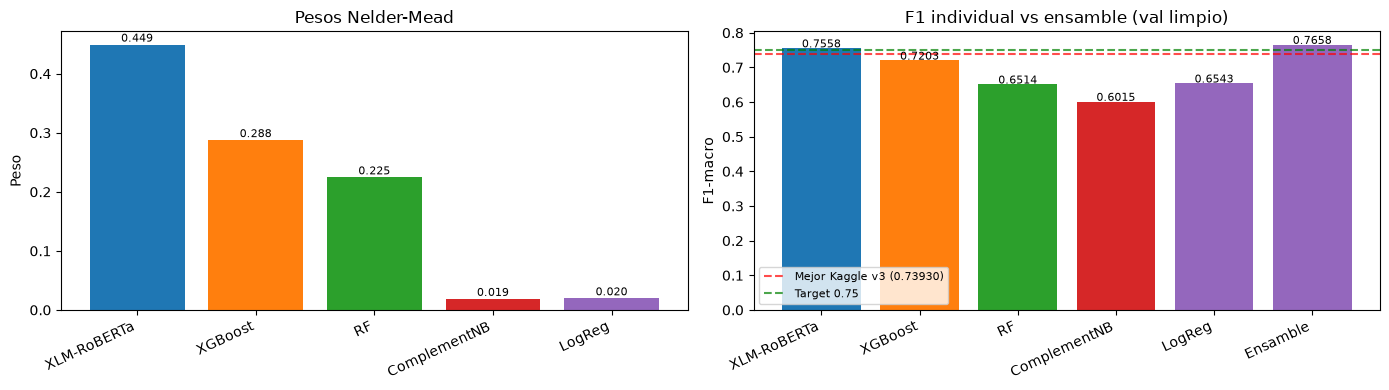

In [14]:
n_models = len(model_names)
colors   = plt.cm.tab10.colors[:n_models]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(n_models), PESOS_OPT, color=colors)
axes[0].set_xticks(range(n_models))
axes[0].set_xticklabels([m.split()[0] for m in model_names], rotation=25, ha="right")
axes[0].set_ylabel("Peso"); axes[0].set_title("Pesos Nelder-Mead")
for i, w in enumerate(PESOS_OPT):
    axes[0].text(i, w + 0.005, f"{w:.3f}", ha="center", fontsize=8)

f1_vals = f1_individuals + [f1_score(y_val, y_pred_val, average="macro")]
labels  = [m.split()[0] for m in model_names] + ["Ensamble"]
colors6 = list(colors) + ["#9467bd"]
bars = axes[1].bar(range(len(f1_vals)), f1_vals, color=colors6)
axes[1].axhline(y=0.73930, color="red",   linestyle="--", alpha=0.7, label="Mejor Kaggle v3 (0.73930)")
axes[1].axhline(y=0.75,    color="green", linestyle="--", alpha=0.7, label="Target 0.75")
axes[1].set_xticks(range(len(f1_vals)))
axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].set_ylabel("F1-macro"); axes[1].set_title("F1 individual vs ensamble (val limpio)")
axes[1].legend(fontsize=8)
for bar, v in zip(bars, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 10. Generación de submission

Para la submission, los modelos sklearn se reentrenan sobre **train + val** (todo el dataset original + EDA aug).
Los modelos transformer se cargan tal cual fueron guardados (ya usan todo el train disponible).

In [15]:
# ── Reentrenar sklearn sobre datos completos (train + val) ────────────────────
print("Reentrenando XGBoost sobre datos completos (EDA aug)...")
df_full_xgb = pd.concat([
    df_original[["text", "label"]],
    df_eda_synth[["text", "label"]]
], ignore_index=True)
X_full_xgb_c = np.array([clean_classical(t) for t in df_full_xgb["text"].values])
y_full_xgb   = df_full_xgb["label"].values.astype(int)
w_full_xgb   = compute_sample_weight("balanced", y_full_xgb)
pipe_xgb.fit(X_full_xgb_c, y_full_xgb, xgb__sample_weight=w_full_xgb)
print(f"XGBoost reentrenado sobre {len(df_full_xgb):,} muestras.")

print("\nReentrenando RF sobre datos completos (solo orig)...")
X_full_rf_c = np.array([clean_classical(t) for t in df_original["text"].values])
y_full_rf   = df_original["label"].values.astype(int)
pipe_rf.fit(X_full_rf_c, y_full_rf)
print(f"RF reentrenado sobre {len(df_original):,} muestras.")

print("\nReentrenando CNB y LR sobre datos completos (LLM aug)...")
df_full_lin = pd.concat([
    df_original[["text", "label"]],
    df_llm_synth[["text", "label"]]
], ignore_index=True)
X_full_lin_c = np.array([clean_classical(t) for t in df_full_lin["text"].values])
y_full_lin   = df_full_lin["label"].values.astype(int)
pipe_cnb.fit(X_full_lin_c, y_full_lin)
pipe_lr.fit(X_full_lin_c, y_full_lin)
print(f"CNB y LR reentrenados sobre {len(df_full_lin):,} muestras.")

Reentrenando XGBoost sobre datos completos (EDA aug)...
XGBoost reentrenado sobre 67,000 muestras.

Reentrenando RF sobre datos completos (solo orig)...
RF reentrenado sobre 51,000 muestras.

Reentrenando CNB y LR sobre datos completos (LLM aug)...
CNB y LR reentrenados sobre 66,553 muestras.


In [16]:
test_probs_list = []

# 1. XLM-RoBERTa N13 Large
print("[1/5] XLM-RoBERTa N13 Large — test probs")
test_probs_list.append(get_transformer_probs(XLM_DIR, X_test_m))

# 2. XGBoost (reentrenado sobre full)
print("\n[2/5] XGBoost — test probs")
test_probs_list.append(get_sklearn_probs(pipe_xgb, X_test_c))

# 3. RF (reentrenado sobre full)
print("\n[3/5] RF — test probs")
test_probs_list.append(get_sklearn_probs(pipe_rf, X_test_c))

# 4. CNB (reentrenado sobre full)
print("\n[4/5] CNB — test probs")
test_probs_list.append(get_sklearn_probs(pipe_cnb, X_test_c))

# 5. LR (reentrenado sobre full)
print("\n[5/5] LR — test probs")
test_probs_list.append(get_sklearn_probs(pipe_lr, X_test_c))

print(f"\nProbabilidades test listas: {len(test_probs_list)} modelos")

[1/5] XLM-RoBERTa N13 Large — test probs
  Cargando transformer: red_neuronal_xlm_roberta_n13_large...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


[2/5] XGBoost — test probs

[3/5] RF — test probs

[4/5] CNB — test probs

[5/5] LR — test probs

Probabilidades test listas: 5 modelos


In [17]:
Path("submissions").mkdir(exist_ok=True)

test_probs_ensemble = sum(w * p for w, p in zip(PESOS_OPT, test_probs_list))
y_pred_test = np.argmax(test_probs_ensemble, axis=1)

sub = pd.DataFrame({"id": test_df["id"].values, "label": y_pred_test.astype(int)})
sub_path = f"submissions/submission_{NOMBRE_ENTREGA}.csv"
sub.to_csv(sub_path, index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: {sub_path} ({len(sub)} predicciones)")
print(f"Distribución: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")
print(f"\nF1 val limpio esperado → Kaggle: {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print(f"Target Kaggle: 0.7500")

Guardado: submissions/submission_ensamble_5modelos_nelder_v9.csv (8500 predicciones)
Distribución: clase 0: 39.3%, clase 1: 22.4%, clase 2: 38.3%

F1 val limpio esperado → Kaggle: 0.7658
Target Kaggle: 0.7500


## 11. Análisis de errores (clase neutra)

In [18]:
CLASS_NAMES = ["negativa", "neutra", "positiva"]

# F1 por clase de cada modelo y del ensamble
print("F1 por clase (val limpio):")
header = f"{'Modelo':<22} {'F1-neg':>8} {'F1-neu':>8} {'F1-pos':>8} {'F1-mac':>8}"
print(header)
print("-" * len(header))

for name, probs in zip(model_names, val_probs_list):
    preds = np.argmax(probs, axis=1)
    f1_per = f1_score(y_val, preds, average=None, zero_division=0)
    f1_mac = f1_score(y_val, preds, average="macro")
    print(f"{name:<22} {f1_per[0]:>8.4f} {f1_per[1]:>8.4f} {f1_per[2]:>8.4f} {f1_mac:>8.4f}")

f1_ens_per = f1_score(y_val, y_pred_val, average=None, zero_division=0)
f1_ens_mac = f1_score(y_val, y_pred_val, average="macro")
print("-" * len(header))
print(f"{'ENSAMBLE':<22} {f1_ens_per[0]:>8.4f} {f1_ens_per[1]:>8.4f} {f1_ens_per[2]:>8.4f} {f1_ens_mac:>8.4f}")

F1 por clase (val limpio):
Modelo                   F1-neg   F1-neu   F1-pos   F1-mac
----------------------------------------------------------
XLM-RoBERTa N13 Large    0.8349   0.5558   0.8767   0.7558
XGBoost BoW EDA          0.7917   0.5502   0.8191   0.7203
RF TF-IDF v5             0.7524   0.4262   0.7755   0.6514
ComplementNB TF-IDF      0.7587   0.2745   0.7713   0.6015
LogReg TF-IDF            0.7834   0.3791   0.8004   0.6543
----------------------------------------------------------
ENSAMBLE                 0.8440   0.5743   0.8792   0.7658
